---
title: "Demo SVD dengan 1 wajah"
date: 2026-05-24
---

## SVD (Singular Value Decomposition) pada Wajah Tunggal

### **Instruksi Tugas:**
1. Menampilkan satu gambar wajah tunggal.
2. Menampilkan matriks piksel dari gambar tersebut.
3. Memecah matriks gambar (dipecah menjadi USV melalui proses SVD).
4. Mengetahui ukuran-ukuran matriks (dimensi sebelum dan sesudah dipecah).
5. Mengetahui matriks hasil dekomposisi SVD ($U$, $S$, dan $V^T$ Transpose) serta ukurannya.
6. Mengembalikan matriks ke bentuk awal dengan cara mengalikan USV menggunakan perkalian matriks.
7. Menampilkan kembali dimensi dari matriks hasil rekonstruksi tersebut.

### **1. Menampilkan Satu Gambar Wajah Tunggal**

Langkah pertama adalah membaca file gambar wajah asli (`face_000.png`) dalam format skala abu-abu (*grayscale*), lalu menampilkan visualisasi gambarnya.

Gambar berhasil dibaca


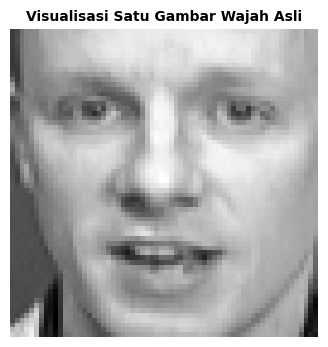

In [49]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# definisikan path gambar
path_gambar = "eigenfaces/face_000.png"
gambar = cv2.imread(path_gambar, cv2.IMREAD_GRAYSCALE)

if gambar is None:
    print("Gambar tidak ditemukan")
else:
    print("Gambar berhasil dibaca")

    # tampilkan Gambar menggunakan matplotlib
    plt.figure(figsize=(4, 4))
    plt.imshow(gambar, cmap='gray')
    plt.title("Visualisasi Satu Gambar Wajah Asli", fontsize=10, fontweight='bold')
    plt.axis('off')
    plt.show()

### **2. Menampilkan Matriks Piksel dari Gambar face_000.png**

Tampilkan matriks piksel 2D asli dari gambar wajah yang telah dibaca. Setiap elemen matriks menyatakan intensitas warna piksel dari 0 (hitam) hingga 255 (putih).

In [50]:
if gambar is not None:
    print("Matriks Piksel Gambar 2D (Matriks A)")
    print(gambar)
    print(f"\nTipe Data Matriks: {gambar.dtype}")

Matriks Piksel Gambar 2D (Matriks A)
[[ 50  60  89 ... 128 134 134]
 [ 49  62  92 ... 128 131 134]
 [ 50  64  91 ... 130 130 133]
 ...
 [ 91 145 142 ...  29  20  25]
 [142 154 147 ...  18  18  32]
 [159 150 160 ...  15  32  23]]

Tipe Data Matriks: uint8


### **3. Memecah Matriks Gambar (Dipecah Menjadi USV)**

Metode dekomposisi SVD memecah matriks 2D wajah $A$ secara langsung menjadi tiga buah matriks: $U$, $\Sigma$ (diagonal $S$), dan $V^T$ ($A = U \cdot \Sigma \cdot V^T$).

In [51]:
if gambar is not None:
    # konversi tipe data matriks gambar ke float agar presisi saat didekomposisi
    A = gambar.astype(float)
    
    print("Melakukan Dekomposisi SVD langsung pada matriks 2D wajah")

    # lakukan dekomposisi SVD menggunakan Numpy
    U, S, Vt = np.linalg.svd(A, full_matrices=False)
    print("Matriks dipecah menjadi matriks U, vektor S, dan matriks Vt")

Melakukan Dekomposisi SVD langsung pada matriks 2D wajah
Matriks dipecah menjadi matriks U, vektor S, dan matriks Vt


### **4. Mengetahui Ukuran-Ukuran Matriks (Dimensi Sebelum & Sesudah Dipecah)**

Periksa dimensi/ukuran dari matriks wajah awal sebelum didekomposisi, serta ukuran matriks-matriks penyusunnya sesudah dipecah.

**Penjelasan Asal-Usul & Perhitungan Dimensi Matriks SVD:**

Secara matematis, SVD memfaktorkan matriks 2D $A$ berukuran $M \times N$ ($64 \times 64$) menjadi perkalian tiga matriks: $A = U \cdot \Sigma \cdot V^T$. Berikut adalah asal-usul dan bagaimana matematika menghitung dimensi dari masing-masing matriks tersebut:

1. **Matriks Gambar Asli $A$ (Ukuran $64 \times 64$):**
   * **Asal-usul & Perhitungan:** Dimensi ini murni berasal dari resolusi spasial foto digital `face_000.png` yang Anda gunakan, yaitu memiliki tinggi $M = 64$ piksel dan lebar $N = 64$ piksel. Hal ini membentuk matriks piksel 2D dengan dimensi **$64 \times 64$**.

2. **Matriks $U$ (Ukuran $64 \times 64$):**
   * **Asal-usul & Perhitungan:** Matriks $U$ berisi *Left Singular Vectors*. Kolom-kolom di dalam matriks $U$ dihitung dari **vektor eigen** (*eigenvectors*) dari matriks hasil kali $A \cdot A^T$.
   * **Perhitungan Dimensi:** Karena dimensi matriks $A$ adalah $64 \times 64$, maka perkalian matriks $A$ dengan transposenya $A^T$ (berukuran $64 \times 64$) akan menghasilkan matriks baru berukuran $64 \times 64$. Oleh karena itu, matriks $U$ yang menampung vektor eigen hasil perhitungan ini berdimensi **$64 \times 64$**.

3. **Matriks $V^T$ (Ukuran $64 \times 64$):**
   * **Asal-usul & Perhitungan:** Matriks $V^T$ berisi *Right Singular Vectors Transpose*. Baris-baris di dalam matriks $V^T$ dihitung dari **vektor eigen** (*eigenvectors*) dari matriks hasil kali $A^T \cdot A$.
   * **Perhitungan Dimensi:** Sama seperti matriks $U$, perkalian matriks transpose $A^T$ (berukuran $64 \times 64$) dengan matriks $A$ (berukuran $64 \times 64$) menghasilkan matriks berukuran $64 \times 64$. Vektor eigen dari matriks hasil kali ini kemudian ditranspose menjadi matriks $V^T$ dengan dimensi **$64 \times 64$**.

4. **Vektor $S$ (Ukuran $64$):**
   * **Asal-usul & Perhitungan:** Nilai singular (*singular values*) di dalam array $S$ diperoleh dari **akar kuadrat dari nilai eigen** ($\sqrt{\lambda}$) dari matriks $A^T \cdot A$ atau $A \cdot A^T$. Nilai singular ini melambangkan besarnya energi/variansi informasi gambar wajah pada masing-masing sumbu koordinat baru.
   * **Perhitungan Dimensi:** Karena matriks $A^T \cdot A$ berukuran $64 \times 64$, maka ia memiliki tepat sebanyak $\min(M, N) = 64$ nilai eigen. Oleh karena itu, array $S$ yang menampung nilai singular ini memiliki dimensi panjang **64** (dinyatakan sebagai `(64,)` di Python). Ketika direkonstruksi kembali, vektor $S$ diubah menjadi matriks diagonal $\Sigma$ berukuran **$64 \times 64$** agar secara aljabar linear dapat dikalikan dengan $U$ dan $V^T$.

In [52]:
if gambar is not None:
    print("Dimensi Sebelum & Sesudah Dipecah")
    print(f"1. Matriks Sebelum Dipecah (Matriks A) : {A.shape} (Tinggi x Lebar)")
    print(f"2. Matriks U  (Left Singular Vectors)  : {U.shape}")
    print(f"3. Vektor S   (Singular Values Array)  : {S.shape}")
    print(f"4. Matriks Vt (V Transpose)            : {Vt.shape}")

Dimensi Sebelum & Sesudah Dipecah
1. Matriks Sebelum Dipecah (Matriks A) : (64, 64) (Tinggi x Lebar)
2. Matriks U  (Left Singular Vectors)  : (64, 64)
3. Vektor S   (Singular Values Array)  : (64,)
4. Matriks Vt (V Transpose)            : (64, 64)


### **5. Mengetahui Matriks Hasil Dekomposisi SVD ($U$, $S$, dan $V^T$) Serta Ukurannya**

Penjelasan singkat mengenai peran dan ukuran dari masing-masing matriks hasil dekomposisi SVD agar dipahami secara akademis.

In [53]:
if gambar is not None:
    print("Matriks Hasil Dekomposisi SVD & Ukurannya")
    print(f"- Matriks U  : Ukuran {U.shape} -> Menyimpan arah kolom basis gambar wajah.")
    print(f"- Vektor S   : Ukuran {S.shape}  -> Menyimpan 64 nilai singular/bobot energi informasi wajah.")
    print(f"- Matriks Vt : Ukuran {Vt.shape} -> Menyimpan arah baris basis gambar wajah.")

Matriks Hasil Dekomposisi SVD & Ukurannya
- Matriks U  : Ukuran (64, 64) -> Menyimpan arah kolom basis gambar wajah.
- Vektor S   : Ukuran (64,)  -> Menyimpan 64 nilai singular/bobot energi informasi wajah.
- Matriks Vt : Ukuran (64, 64) -> Menyimpan arah baris basis gambar wajah.


### **6. Mengembalikan Matriks ke Bentuk Awal Menggunakan Perkalian Matriks**

Susun kembali gambar wajah semula dari komponen dekomposisinya dengan mengalikan matriks $U \cdot \Sigma \cdot V^T$. Di Python, kita ubah vektor $S$ menjadi matriks diagonal $\Sigma$ menggunakan `np.diag(S)`, lalu dikalikan dengan operator `@`.

Memulai proses rekonstruksi matriks gambar asli
Rekonstruksi selesai


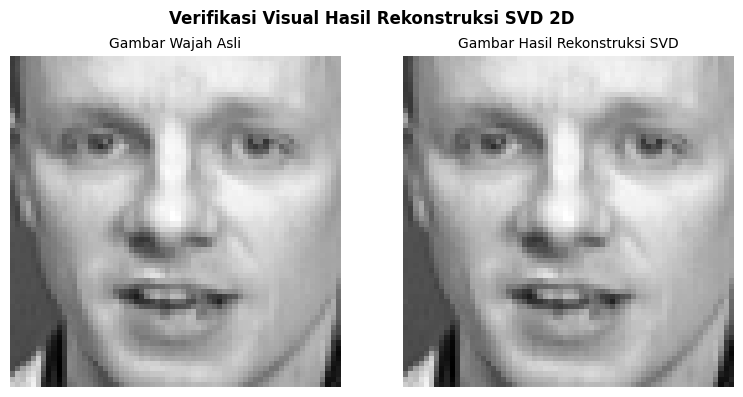

In [54]:
if gambar is not None:
    print("Memulai proses rekonstruksi matriks gambar asli")
    
    # mengubah array S menjadi matriks diagonal Sigma 2D berukuran (64, 64)
    Sigma = np.diag(S)
    
    # mengalikan U * Sigma * Vt menggunakan operator '@'
    A_reconstructed = U @ Sigma @ Vt
    
    # mengubah kembali tipe datanya menjadi uint8 (piksel 0-255)
    gambar_rekonstruksi = np.clip(A_reconstructed, 0, 255).astype(np.uint8)
    print("Rekonstruksi selesai")
    
    # tampilkan perbandingan visual
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(gambar, cmap='gray')
    plt.title("Gambar Wajah Asli", fontsize=10)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(gambar_rekonstruksi, cmap='gray')
    plt.title("Gambar Hasil Rekonstruksi SVD", fontsize=10)
    plt.axis('off')
    
    plt.suptitle("Verifikasi Visual Hasil Rekonstruksi SVD 2D", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### **7. Menampilkan Kembali Dimensi dari Matriks Hasil Rekonstruksi**

tampilkan kembali dimensi dari matriks hasil rekonstruksi di Poin 6 dan memverifikasi apakah ia sama persis dengan matriks gambar asli sebelum dipecah.

In [55]:
if gambar is not None:
    print("Verifikasi Dimensi & Kesamaan Matriks")
    print(f"1. Dimensi Matriks Hasil Rekonstruksi : {gambar_rekonstruksi.shape} (Kembali ke bentuk awal!)")
    
    # uji kesamaan matematis
    apakah_sama = np.allclose(A, A_reconstructed)
    print(f"2. Apakah hasil rekonstruksi sama persis/mendekati matriks asli? {apakah_sama}")

Verifikasi Dimensi & Kesamaan Matriks
1. Dimensi Matriks Hasil Rekonstruksi : (64, 64) (Kembali ke bentuk awal!)
2. Apakah hasil rekonstruksi sama persis/mendekati matriks asli? True
